### `etd-rk2.ipyng`  
*Created June 12, 2026*

**Description:** This notebook implements the second-order ETD-RK2 method, an exponential time differencing (ETD) integrator for ODE systems of the form 
$$ \frac{du}{dt} = Au + F(u,t) $$ 

where $A$ is an $N \times N$ matrix and $F$ is a non-linear function from $\mathbb{R}^N \times \mathbb{R}$ to $\mathbb{R}^N$. The ETD-RK2 algorithm is as follows: 
\begin{align*}
    a_n &= u_n e^{\Delta t A} + \Delta t \,\big[\varphi_1(\Delta t A) F(u_n,t_n) \big]  \\[5pt]
   u_{n+1} &= a_n + \Delta t \, \varphi_2(\Delta t A) \,\left[F(a_n,t_{n+1}) - F(a_n,t_n) \right]
\end{align*}

where $\varphi_1(\Delta t A)$ and $\varphi_2(\Delta t A)$ are $N \times N$ vectors, and $N(u_n,t_n)$ and $F(a_n,t_n)$ are $N \times 1$ column vectors and 
\begin{align*}
   \varphi_1(z) = \frac{e^z - 1}{z} \qquad \text{ and } \qquad \varphi_2(z) = \frac{e^z - 1 - z}{z^2} \qquad \text{for } z \in \mathbb{C}.
\end{align*}

\begin{align*}
  \scriptstyle \varphi_1\left(\begin{bmatrix} \lambda_1 & & \\ & \ddots & \\ & & \lambda_N \end{bmatrix} \right) = \begin{bmatrix} \varphi_1(\lambda_1) & & \\ & \ddots & \\  & & \varphi_1(\lambda_N) \end{bmatrix} \qquad \text{ and } \qquad \scriptstyle \varphi_2\left(\begin{bmatrix} \lambda_1 & & \\ & \ddots & \\ & & \lambda_N \end{bmatrix} \right) = \begin{bmatrix} \varphi_2(\lambda_1) & & \\ & \ddots & \\  & & \varphi_2(\lambda_N) \end{bmatrix}, \qquad \lambda_1,\ldots,\lambda_N \in \mathbb{C}
\end{align*}


\begin{align*}
   \varphi_1(B) := \sum_{k=0}^{\infty} \frac{B^k}{(k+1)!} \qquad \text{and} \qquad \varphi_2(B) := \sum_{k=0}^{\infty} \frac{B^k}{(k+2)!} \qquad \text{for } B \in \mathbb{C}^{N \times N}. 
\end{align*}

In [1]:
using Pkg; 
@time using CairoMakie
@time using OrdinaryDiffEq
@time using LinearAlgebra
@time using LaTeXStrings
@time using Random
@time using Printf
@time using NBInclude
@time using Statistics
@time using UnPack
@nbinclude("..\\set_makie_defaults.ipynb")

 63.069935 seconds (4.30 M allocations: 262.209 MiB, 1.68% gc time, 0.54% compilation time: 61% of which was recompilation)
 44.592280 seconds (3.48 M allocations: 227.757 MiB, 2.02% gc time, 0.27% compilation time: 49% of which was recompilation)
  0.001489 seconds (328 allocations: 18.312 KiB)
  0.001191 seconds (328 allocations: 18.312 KiB)
  0.018821 seconds (787 allocations: 48.836 KiB)
  0.001294 seconds (328 allocations: 18.305 KiB)
  0.110420 seconds (2.79 k allocations: 171.099 KiB)
  0.019731 seconds (825 allocations: 52.562 KiB)
  0.001277 seconds (328 allocations: 18.305 KiB)


LoadError: SystemError: opening file "C:\\Users\\mbarm\\Documents\\Documents\\01_GradSchool\\03_code\\diff-eq-tools\\set_makie_defaults.ipynb": No such file or directory

In [2]:
#phi functions for scalar arguments 
function phi1(z::Number)
    return expm1(z) / z  
end 

function phi2(z::Number)
    return (expm1(z) - z) / z 
end

phi2 (generic function with 1 method)

In [3]:
#phi functions for matrix arguments 
function phi1(B::AbstractMatrix)

    #Check that B is a square matrix 
    N = size(B,1) 
    size(B,1) == size(B,2) || throw(ArgumentError("phi1() is only defined for square matrices. You passed a non-square matrix."))

    #Compute phi1(B) for diagonal B 
    if B isa Diagonal   
        return Diagonal(phi1.(B.diag))
    end 

    #Compute phi1(B) for general B
    T = promote_type(eltype(B), Float64)   #Get type suitable for mixed arithmetic w/ Float64's and entries of B
    B = Matrix{T}(B)                       #Convert B to be matrix of eltype T. 
    Z = zeros(T, N, N)                     #N x N zero matrix 
    Iₙ = Matrix{T}(I, N, N)                #N x N identity matrix 
    
    M = exp([B Iₙ
             Z Z])                        #Matrix exponential (e^A = I + A + A^2/2! + A^3/3! + ⋯) 
    
    return M[1:N, N+1:end]  
end 

phi1 (generic function with 2 methods)

In [4]:
function phi2(B::AbstractMatrix)

    N = size(B, 1)    
    size(B, 1) == size(B, 2) || throw(ArgumentError("phi2(B) is only defined for square matrices B. Matrix has size $(size(B))"))

    #Compute phi2(B) for diagonal B 
    if B isa Diagonal
        return Diagonal(phi2.(B.diag))
    end 

    T = promote_type(eltype(B), Float64)   #Get common type for mixed arithmetic with B and Float64's 
    B = Matrix{T}(B)
    Z = zeros(T, N, N) 
    Iₙ = Matrix{T}(I, N, N)
    
    M = [B Iₙ Z
         Z Z Iₙ 
         Z Z Z] 

    exp_M = exp(M)
    return exp_M[1:N, 2*N+1:3*N]
end 

phi2 (generic function with 2 methods)

In [5]:
function etd_rk2(A, f, u0; tspan, Δt, p = nothing)

    """
    PARAMETERS:
    ----------
    A :: N x N constant matrix
    f :: nonlinear function from R^N to R^N 
    u0 :: initial condition (vector of length N)
    Δt :: step size 
    p :: parameter for the function `f` (if required)  
    """
    
    t0, tf = tspan
    M = floor(Int, (tf - t0) / Δt)                      #Number of time subintervals
    t = collect(range(t0, t0 + M*Δt, length = M + 1))   #Time values at which to record the solution (incl t0)
    u = [zero(u0) for j=1:M+1]                          #Vector (of vectors) to store the solution iterates u_0,…,u_M
    u[1] = u0

    #Compute the necessary matrices (fixed across all time steps) 
    E = exp(Δt*A) 
    Φ₁ = phi1(Δt*A)
    Φ₂ = phi2(Δt*A) 

    for n=1:M      #Compute u[2],...,u[M+1] 
        a = E * u[n] + Δt * Φ₁ * f(u[n], p, t[n])
        u[n+1] = a + Δt * Φ₂ * (f(a, p, t[n+1]) - f(u[n], p, t[n]))
    end 

    return (u = u, t = t, Δt = Δt, p = p) 
end 

etd_rk2 (generic function with 1 method)

In [6]:
#TESTING OUT ETD-RK2 using a system of 2 equations 
A = [-100.0 0.0; 0.0 -1.0]
u0 = [0.0, 1.0]

function f(u,p,t)
    f1 = cos(t) + 100*sin(t) + (u[1])^2 - (sin(t))^2 
    f2 = -sin(t) + cos(t) + u[1] * u[2] - sin(t) * cos(t)
    return [f1, f2]
end 

u_exact(t) = [sin(t), cos(t)]

@time out = etd_rk2(A, f, u0; tspan = (0, 3.0), Δt = 0.05, p = 1);

  6.893134 seconds (4.09 M allocations: 203.936 MiB, 3.07% gc time, 99.73% compilation time)


RMSE_u = 2.2374e-04
RMSE_v = 1.0791e-02


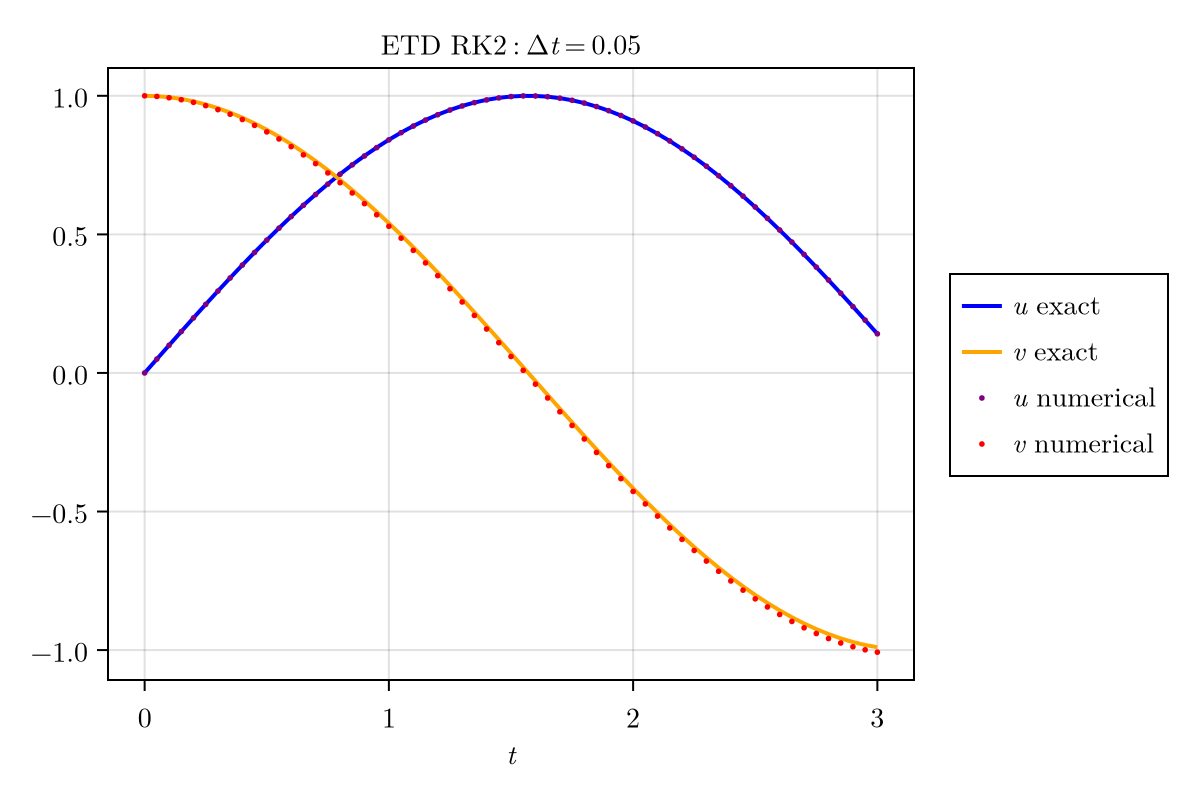

CairoMakie.Screen{IMAGE}


In [7]:
sol = out.u
t = out.t
Δt = out.Δt

u_num = getindex.(sol,1)
v_num = getindex.(sol,2)

ex_sol = u_exact.(t)
u_ex = getindex.(ex_sol, 1)
v_ex = getindex.(ex_sol, 2);

@printf("RMSE_u = %.4e\n", mean(sqrt.((u_ex .- u_num).^2))) 
@printf("RMSE_v = %.4e\n", mean(sqrt.((v_ex .- v_num).^2))) 
 
fig = Figure(size = (600,400))

Δt_str = @sprintf("%.2f", Δt)
ax = Axis(fig[1,1], xlabel = L"t", title = L"\textrm{ETD RK2:} Δt = %$(Δt_str)")
lines!(ax, t, u_ex, color = :blue, linewidth = 2, label = L"u \textrm{ exact}")
lines!(ax, t, v_ex, color = :orange, linewidth = 2, label = L"v \textrm{ exact}")

scatter!(ax, t, u_num, color = :purple, markersize = 4, label = L"u \textrm{ numerical}")
scatter!(ax, t, v_num, color = :red, markersize = 4, label = L"v \textrm{ numerical}")

Legend(fig[1,2], ax)
#axislegend(ax, position = :rt)
display(fig)